# **MSDS-696 Data Science Practicum 2 Mutli-Class Infrastructure Damage Classification using Remote Aerial Sensing**
## Notebook 4 — Model Benchmarking: 5 CNN Architectures
`Author: Chennakeshava Akhil Pillalamarri`  
`Regis University`

This notebook is the main benchmarking notebook for Week 4. The goal is to train five different CNN architectures fom scratch on the LADI v2 dataset and compare them against each other using Macro F1 as the primary metric.

All models are built with no pretrained weights as required by the course guidelines. The five architectures I am benchmarking are:

- Model 1 — VGG-16 Inspired CNN
- Model 2 — ResNet-18 Inspired CNN
- Model 3 — Inception V1 Inspired CNN
- Model 4 — Base Custom CNN (Retrained with improved pipeline)
- Model 5 — DenseNet-40 Inspired CNN

`Note: I have used the mentioned model style CNN architectures, but have mentioned in the code as styled cnn models.`

## 1. Imports

Loading all the required libraries. I am also importing the functional API components this time: Input, Add, Concatenate, AveragePooling2D — since the ResNet, Inception, and DenseNet architectures need branching layers that cannot be built with the Sequential API.

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, regularizers, backend
from tensorflow.keras.layers import Add, Input, Concatenate, AveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
base_path        = r"C:\Users\kesha\Desktop\MSDS-696_DSP-2"
preprocessed_dir = os.path.join(base_path, "preprocessed_dataset")
train_dir        = os.path.join(preprocessed_dir, "train")
val_dir          = os.path.join(preprocessed_dir, "validation")
test_dir         = os.path.join(preprocessed_dir, "test")

os.chdir(base_path)
print(os.getcwd())

C:\Users\kesha\Desktop\MSDS-696_DSP-2


In [3]:
for split_name, split_dir in [("train", train_dir),
                               ("validation", val_dir),
                               ("test", test_dir)]:
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(os.listdir(os.path.join(split_dir, cls)))
        print(split_name, cls, count)
        total += count
    print(split_name, "total:", total)
    print("-------------")

train Intact 6542
train Major_Damage 4284
train Structural_Failure 11132
train total: 21958
-------------
validation Intact 710
validation Major_Damage 585
validation Structural_Failure 1265
validation total: 2560
-------------
test Intact 1001
test Major_Damage 22
test Structural_Failure 26
test total: 1049
-------------


In [4]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)
print("Train images     :", train_generator.samples)
print("Validation images:", validation_generator.samples)
print("Test images      :", test_generator.samples)

Found 21958 images belonging to 3 classes.
Found 2560 images belonging to 3 classes.
Found 1049 images belonging to 3 classes.
{'Intact': 0, 'Major_Damage': 1, 'Structural_Failure': 2}
Train images     : 21958
Validation images: 2560
Test images      : 1049


In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.1188219708549882, 1: 1.7085278555866792, 2: 0.6575038926817582}


In [ ]:
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce     = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.pow(1 - y_pred, gamma)
        fl     = weight * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=1))
    return focal_loss_fn

def macro_f1(y_true, y_pred):
    y_true    = tf.cast(y_true, tf.float32)
    y_pred    = tf.cast(tf.round(y_pred), tf.float32)
    f1_scores = []
    for i in range(3):
        tp        = K.sum(y_true[:, i] * y_pred[:, i])
        fp        = K.sum((1 - y_true[:, i]) * y_pred[:, i])
        fn        = K.sum(y_true[:, i] * (1 - y_pred[:, i]))
        precision = tp / (tp + fp + K.epsilon())
        recall    = tp / (tp + fn + K.epsilon())
        f1        = 2 * precision * recall / (precision + recall + K.epsilon())
        f1_scores.append(f1)
    return tf.reduce_mean(tf.stack(f1_scores))

In [13]:
class BalancedGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, batch_size=33, target_size=(128, 128)):
        self.batch_size        = batch_size
        self.target_size       = target_size
        self.classes           = ['Intact', 'Major_Damage', 'Structural_Failure']
        self.class_files       = {}
        self.samples_per_class = batch_size // len(self.classes)

        for i, cls in enumerate(self.classes):
            cls_dir = os.path.join(directory, cls)
            files   = [os.path.join(cls_dir, f)
                      for f in os.listdir(cls_dir) if f.endswith('.jpg')]
            self.class_files[i] = files
            print(cls, "files:", len(files))

        self.steps = min(
            len(f) for f in self.class_files.values()) // self.samples_per_class
        print("Steps per epoch:", self.steps)

    def __len__(self):
        return self.steps

    def __getitem__(self, idx):
        from tensorflow.keras.preprocessing.image import load_img, img_to_array
        batch_x = []
        batch_y = []

        for class_idx in range(len(self.classes)):
            files  = self.class_files[class_idx]
            chosen = np.random.choice(files, self.samples_per_class, replace=True)
            for fpath in chosen:
                img              = load_img(fpath, target_size=self.target_size)
                img              = img_to_array(img) / 255.0
                label            = np.zeros(len(self.classes))
                label[class_idx] = 1
                batch_x.append(img)
                batch_y.append(label)

        batch_x = np.array(batch_x)
        batch_y = np.array(batch_y)
        idx_arr = np.arange(len(batch_x))
        np.random.shuffle(idx_arr)
        return batch_x[idx_arr], batch_y[idx_arr]

balanced_gen = BalancedGenerator(train_dir, batch_size=33, target_size=(128, 128))

Intact files: 6542
Major_Damage files: 4284
Structural_Failure files: 11132
Steps per epoch: 389


In [9]:
def plot_history(history, model_name):
    history_dict    = history.history
    loss_values     = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    acc_values      = history_dict['accuracy']
    val_acc_values  = history_dict['val_accuracy']
    epochs          = range(1, len(acc_values) + 1)

    plt.plot(epochs, loss_values, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
    plt.title(model_name + ' - Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
    plt.title(model_name + ' - Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    return plt.show()

In [10]:
def evaluate_model(model, model_name):
    test_generator.reset()
    results      = model.evaluate(test_generator, steps=len(test_generator))
    test_loss    = results[0]
    test_acc     = results[1]
    test_f1      = results[2]

    print(f'{model_name} - Test Accuracy : {test_acc:.4f}')
    print(f'{model_name} - Test Loss     : {test_loss:.4f}')
    print(f'{model_name} - Test Macro F1 : {test_f1:.4f}')

    test_generator.reset()
    preds        = model.predict(test_generator,
                                  steps=len(test_generator), verbose=1)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = test_generator.classes[:len(pred_classes)]
    class_names  = list(test_generator.class_indices.keys())

    print(f"\nClassification Report - {model_name}:")
    print(classification_report(true_classes, pred_classes,
                                 target_names=class_names))
    print("Balanced Accuracy:",
          round(balanced_accuracy_score(true_classes, pred_classes), 4))

    print("\nPer Class Accuracy:")
    for i, cls in enumerate(class_names):
        mask    = np.array(true_classes) == i
        cls_acc = np.mean(np.array(pred_classes)[mask] == i)
        print(f"  {cls}: {int(np.sum(mask))} samples - Accuracy: {cls_acc:.4f}")

    cm = confusion_matrix(true_classes, pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - ' + model_name)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, f'confusion_matrix_{model_name}.png'))
    plt.show()

    return test_acc, test_loss, test_f1, true_classes, pred_classes

In [ ]:
print("=" * 55)
print("WEEK 4 - MODEL BENCHMARKING")
print("=" * 55)
print("All models trained from scratch - no pretrained weights")
print("Same training config for fair comparison:")
print("Optimizer           : Adam lr=1e-4")
print("Loss                : Focal Loss gamma=2.0 alpha=0.25")
print("Metric              : Macro F1")
print("Batch Size          : 33 (11 per class balanced)")
print("Early Stop Metric   : val_macro_f1 patience=5")
print("LR Reduction Metric : val_macro_f1 patience=3")
print("=" * 55)
print("Models:")
print("  Model 2 - VGG Style CNN")
print("  Model 3 - ResNet Style CNN")
print("  Model 4 - Inception Style CNN")
print("  Model 5 - DenseNet Style CNN")
print("=" * 55)

WEEK 4 - MODEL BENCHMARKING
All models trained from scratch - no pretrained weights
Same training config for fair comparison:
Optimizer           : Adam lr=1e-4
Loss                : Focal Loss gamma=2.0 alpha=0.25
Metric              : Macro F1
Batch Size          : 33 (11 per class balanced)
Early Stop Metric   : val_macro_f1 patience=5
LR Reduction Metric : val_macro_f1 patience=3
Models:
  Model 2 - VGG Style CNN
  Model 3 - ResNet Style CNN
  Model 4 - Inception Style CNN
  Model 5 - DenseNet Style CNN


## **Model 2 — VGG-16 Inspired CNN**

Starting with a VGG-16 architecture as the first benchmark. The original VGG paper showed that stacking multiple small 3×3 conv layers back-to-back can learn richer spatial features than a single large kernel layer.

My implementation uses double and triple conv blocks with filter sizes stepping up from 32, 64, 128, 256.

The VGG architecture is being trained on the unaugmented dataset.

In [ ]:
def VGG_DamageCNN():
    backend.clear_session()
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=(128, 128, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy', macro_f1]
    )
    return model

model2 = VGG_DamageCNN()
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,982,883 (7.56 MB)

 Trainable params: 1,979,683 (7.55 MB)

 Non-trainable params: 3,200 (12.50 KB)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 266s 670ms/step - accuracy: 0.6026 - loss: 0.2839 - macro_f1: 0.5787 - val_accuracy: 0.5094 - val_loss: 0.3463 - val_macro_f1: 0.3692 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 259s 666ms/step - accuracy: 0.6733 - loss: 0.2354 - macro_f1: 0.6486 - val_accuracy: 0.4543 - val_loss: 0.6690 - val_macro_f1: 0.3296 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 258s 663ms/step - accuracy: 0.6985 - loss: 0.2171 - macro_f1: 0.6740 - val_accuracy: 0.4820 - val_loss: 1.0542 - val_macro_f1: 0.3600 - learning_rate: 1.0000e-04
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.7103 - loss: 0.2117 - macro_f1: 0.6854
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
389/389 ━━━━━━━━━━━━━━━━━━━━ 258s 662ms/step - accuracy: 0.7140 - loss: 0.2078 - macro_f1: 0.6890 - val_accuracy: 0.4840 - val_loss: 0.5760 - val_macro_f1: 0.3508 - learning_rate: 1.0000e-04
Epoch 5/50
389/389 ━

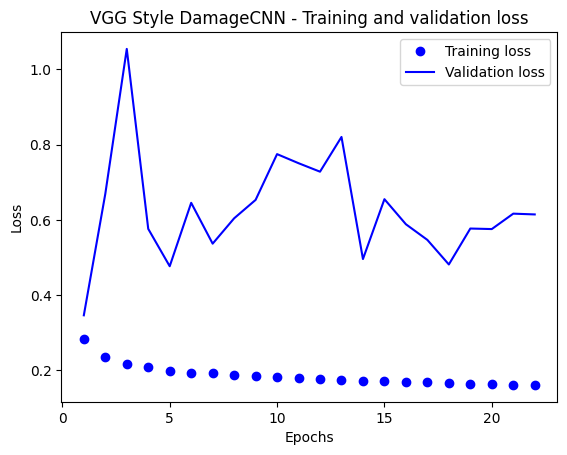

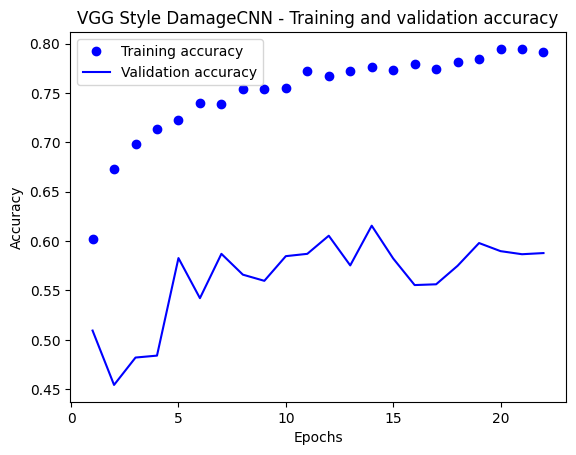

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.9466 - loss: 0.1962 - macro_f1: 0.3163
VGG_DamageCNN - Test Accuracy : 0.9466
VGG_DamageCNN - Test Loss     : 0.1962
VGG_DamageCNN - Test Macro F1 : 0.3163
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step

Classification Report - VGG_DamageCNN:
                    precision    recall  f1-score   support

            Intact       0.95      0.99      0.97      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.00      0.00      0.00        26

          accuracy                           0.95      1049
         macro avg       0.32      0.33      0.32      1049
      weighted avg       0.91      0.95      0.93      1049

Balanced Accuracy: 0.3307

Per Class Accuracy:
  Intact: 1001 samples - Accuracy: 0.9920
  Major_Damage: 22 samples - Accuracy: 0.0000
  Structural_Failure: 26 samples - Accuracy: 0.0000


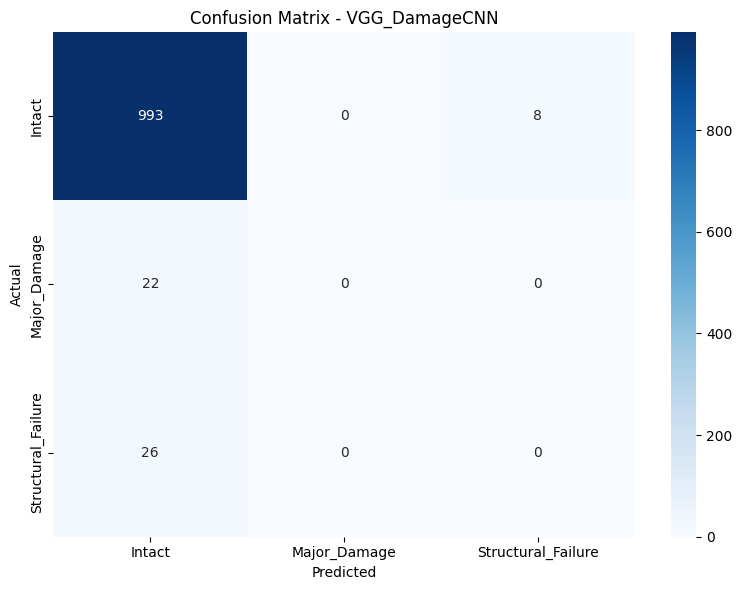

In [23]:
backend.clear_session()
model2 = VGG_DamageCNN()

history2 = model2.fit(
    balanced_gen,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_macro_f1', patience=8,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_macro_f1', factor=0.5,
                          patience=3, verbose=1, mode='max')
    ]
)

plot_history(history2, 'VGG Style DamageCNN')
acc2, loss2, f1_2, true2, pred2 = evaluate_model(model2, 'VGG_DamageCNN')
model2.save(os.path.join(base_path, 'model2_vgg_damagecnn.keras'))

The VGG model trains for 22 epochs before early stopping triggers. Training accuracy climbs steadily to around 0.80 but validation accuracy is very unstable, oscillating heavily throughout training, which suggests this architecture is too heavy and is overfitting on the balanced batches.

The standard evaluation gives a test macro F1 of 0.3163. Both Major Damage and Structural Failure get zero recall, the model is predicting everything as Intact on the test set.

The VGG test accuracy of 0.9466 looks impressive but that number is misleading, it is entirely driven by the 1,001 Intact test samples.

Before going for the next model, I have performed the augmentation after training te VGG-16 model.

## Upgrading to 160×160 Input and Focal Loss gamma=3.0

After seeing the VGG results I am making two adjustments that will apply to all remaining models.

**Input resolution: 128×128 → 160×160**  
At 128×128 a lot of structural detail in aerial damage imagery gets lost. Going up to 160×160 gives the model more spatial information to distinguish subtle damage patterns without making training prohibitively slow on CPU.

**Focal Loss gamma: 2.0 → 3.0**  
With gamma=2.0 the model is still not forcing enough attention onto the minority class samples. Increasing gamma to 3.0 makes the model more aggressive, easy Intact examples get down-weighted even more, and the loss gradient from the rare Major Damage and Structural Failure samples becomes more dominant.

In [ ]:
from sklearn.metrics import f1_score

test_generator.reset()
preds_vgg    = model2.predict(test_generator,
                               steps=len(test_generator), verbose=1)
true_classes = test_generator.classes[:len(preds_vgg)]
class_names  = list(test_generator.class_indices.keys())

best_macro_f1  = 0
best_threshold = 0
best_report    = None

for thresh in [0.25, 0.20, 0.15, 0.12, 0.10, 0.08, 0.05]:
    adjusted = []
    for pred in preds_vgg:
        if pred[2] >= thresh:
            adjusted.append(2)
        elif pred[1] >= thresh:
            adjusted.append(1)
        else:
            adjusted.append(0)

    macro_f1_score = f1_score(true_classes, adjusted, average='macro')
    print(f"Threshold {thresh} - Macro F1: {macro_f1_score:.4f}")

    if macro_f1_score > best_macro_f1:
        best_macro_f1  = macro_f1_score
        best_threshold = thresh
        best_report    = classification_report(
            true_classes, adjusted, target_names=class_names)

print(f"\nBest threshold: {best_threshold}")
print(f"Best macro F1:  {best_macro_f1:.4f}")
print(best_report)

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step
Threshold 0.25 - Macro F1: 0.3351
Threshold 0.2 - Macro F1: 0.3438
Threshold 0.15 - Macro F1: 0.3554
Threshold 0.12 - Macro F1: 0.3486
Threshold 0.1 - Macro F1: 0.3455
Threshold 0.08 - Macro F1: 0.3452
Threshold 0.05 - Macro F1: 0.3298

Best threshold: 0.15
Best macro F1:  0.3554
                    precision    recall  f1-score   support

            Intact       0.96      0.96      0.96      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.09      0.15      0.11        26

          accuracy                           0.92      1049
         macro avg       0.35      0.37      0.36      1049
      weighted avg       0.91      0.92      0.92      1049



In [14]:
balanced_gen = BalancedGenerator(train_dir, batch_size=33, 
                                  target_size=(160, 160))

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(160, 160), batch_size=32, 
    class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(160, 160), batch_size=32, 
    class_mode='categorical')

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(160, 160), batch_size=32,
    class_mode='categorical', shuffle=False)

Intact files: 6542
Major_Damage files: 4284
Structural_Failure files: 11132
Steps per epoch: 389
Found 21958 images belonging to 3 classes.
Found 2560 images belonging to 3 classes.
Found 1049 images belonging to 3 classes.


In [18]:
input_shape=(160, 160, 3)

loss=focal_loss(gamma=3.0, alpha=0.25)

def evaluate_model(model, model_name):
    test_generator.reset()
    results   = model.evaluate(test_generator, steps=len(test_generator))
    test_loss = results[0]
    test_acc  = results[1]
    test_f1   = results[2]

    print(f'{model_name} - Test Accuracy : {test_acc:.4f}')
    print(f'{model_name} - Test Loss     : {test_loss:.4f}')
    print(f'{model_name} - Test Macro F1 : {test_f1:.4f}')

    test_generator.reset()
    preds        = model.predict(test_generator,
                                  steps=len(test_generator), verbose=1)
    true_classes = test_generator.classes[:len(preds)]
    class_names  = list(test_generator.class_indices.keys())

    pred_classes = np.argmax(preds, axis=1)
    print(f"\nClassification Report (standard) - {model_name}:")
    print(classification_report(true_classes, pred_classes,
                                 target_names=class_names))

    best_f1    = 0
    best_thresh = 0
    best_preds  = pred_classes

    for thresh in [0.20, 0.15, 0.12, 0.10, 0.08, 0.05]:
        adjusted = []
        for pred in preds:
            if pred[2] >= thresh:
                adjusted.append(2)
            elif pred[1] >= thresh:
                adjusted.append(1)
            else:
                adjusted.append(0)
        score = f1_score(true_classes, adjusted, average='macro')
        if score > best_f1:
            best_f1     = score
            best_thresh = thresh
            best_preds  = adjusted

    print(f"\nClassification Report (threshold={best_thresh}) - {model_name}:")
    print(classification_report(true_classes, best_preds,
                                 target_names=class_names))
    print("Balanced Accuracy:",
          round(balanced_accuracy_score(true_classes, best_preds), 4))

    print("\nPer Class Accuracy:")
    for i, cls in enumerate(class_names):
        mask    = np.array(true_classes) == i
        cls_acc = np.mean(np.array(best_preds)[mask] == i)
        print(f"  {cls}: {int(np.sum(mask))} samples - Accuracy: {cls_acc:.4f}")

    cm = confusion_matrix(true_classes, best_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - ' + model_name)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, f'confusion_matrix_{model_name}.png'))
    plt.show()

    return test_acc, test_loss, test_f1, true_classes, best_preds

## **Model-3 ResNet-18 Inspired CNN**

Moving on to the ResNet-18 Architecture, insted of learning a direct mapping, the layers learn a residual feature and then add the input back in, solving the vanishing gradient problem andallows much deeper networks to train effectively.

I am implementing this using the functional API since skip connections require tensor addition across branches, which the Sequential API cannot handle. The architecture uses three stages of residual blocks with 64, 128, and 256 filters, with downsampling between stages.

In [ ]:
# Model 3 - ResNet-18 Inspired CNN

def residual_block(x, filters, downsample=False):
    shortcut = x
    stride   = 2 if downsample else 1

    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same',
                      activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3, 3), padding='same',
                      activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride,
                                 padding='same')(shortcut)

    x = Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def ResNet_DamageCNN():
    backend.clear_session()
    inputs = Input(shape=(160, 160, 3))

    x = layers.Conv2D(64, (7, 7), strides=2, padding='same',
                      activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = layers.Dropout(0.25)(x)

    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)
    x = layers.Dropout(0.3)(x)

    x = residual_block(x, 256, downsample=True)
    x = residual_block(x, 256)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=5e-5),
        loss=focal_loss(gamma=3.0, alpha=0.25),
        metrics=['accuracy', macro_f1]
    )
    return model

model3 = ResNet_DamageCNN()
model3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 80,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 80,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 40,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 40,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 40, 40,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 40,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 40,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 40, 40,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 40, 40,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 40, 40,    │          0 │ activation_1[0][

 Total params: 2,855,555 (10.89 MB)

 Trainable params: 2,851,331 (10.88 MB)

 Non-trainable params: 4,224 (16.50 KB)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 155s 379ms/step - accuracy: 0.5360 - loss: 0.3012 - macro_f1: 0.4931 - val_accuracy: 0.2340 - val_loss: 0.3812 - val_macro_f1: 0.1492 - learning_rate: 5.0000e-05
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 145s 373ms/step - accuracy: 0.6347 - loss: 0.2621 - macro_f1: 0.5850 - val_accuracy: 0.5543 - val_loss: 0.2951 - val_macro_f1: 0.5277 - learning_rate: 5.0000e-05
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 146s 374ms/step - accuracy: 0.6769 - loss: 0.2446 - macro_f1: 0.6329 - val_accuracy: 0.6551 - val_loss: 0.2457 - val_macro_f1: 0.5922 - learning_rate: 5.0000e-05
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 145s 373ms/step - accuracy: 0.7040 - loss: 0.2345 - macro_f1: 0.6615 - val_accuracy: 0.6191 - val_loss: 0.2499 - val_macro_f1: 0.5857 - learning_rate: 5.0000e-05
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 145s 372ms/step - accuracy: 0.7068 - loss: 0.2289 - macro_f1: 0.6634 - val_accuracy: 0.6684 - val_loss: 0.2656 - val_macro_f1: 0.6266 - learning_rate: 5

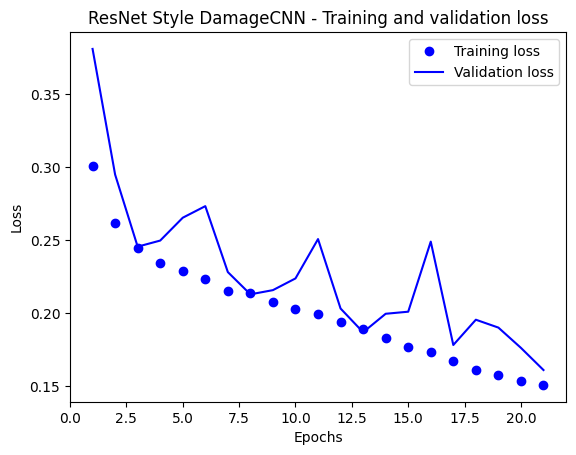

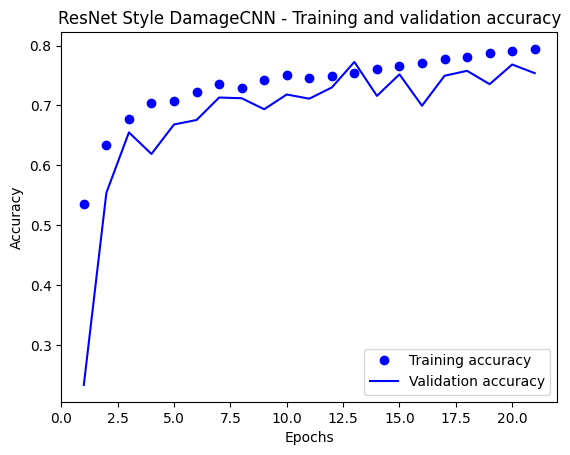

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9056 - loss: 0.1814 - macro_f1: 0.2959
ResNet_DamageCNN - Test Accuracy : 0.9056
ResNet_DamageCNN - Test Loss     : 0.1814
ResNet_DamageCNN - Test Macro F1 : 0.2959
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step

Classification Report (standard) - ResNet_DamageCNN:
                    precision    recall  f1-score   support

            Intact       0.96      0.95      0.95      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.06      0.12      0.08        26

          accuracy                           0.91      1049
         macro avg       0.34      0.35      0.34      1049
      weighted avg       0.92      0.91      0.91      1049



NameError: name 'f1_score' is not defined

In [17]:
backend.clear_session()
model3 = ResNet_DamageCNN()

history3 = model3.fit(
    balanced_gen,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_macro_f1', patience=8,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_macro_f1', factor=0.5,
                          patience=4, verbose=1, mode='max')
    ]
)

plot_history(history3, 'ResNet Style DamageCNN')
acc3, loss3, f1_3, true3, pred3 = evaluate_model(model3, 'ResNet_DamageCNN')
model3.save(os.path.join(base_path, 'model3_resnet_damagecnn.keras'))

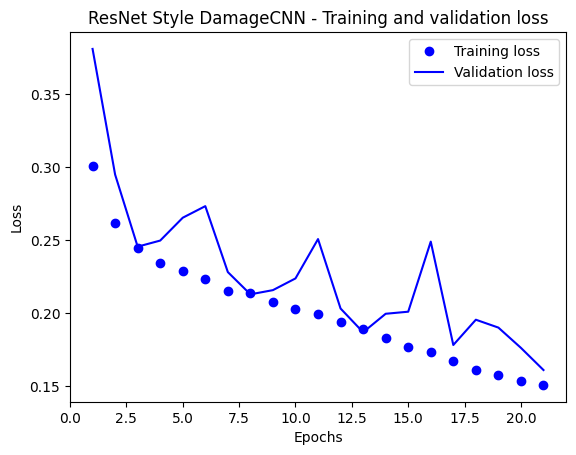

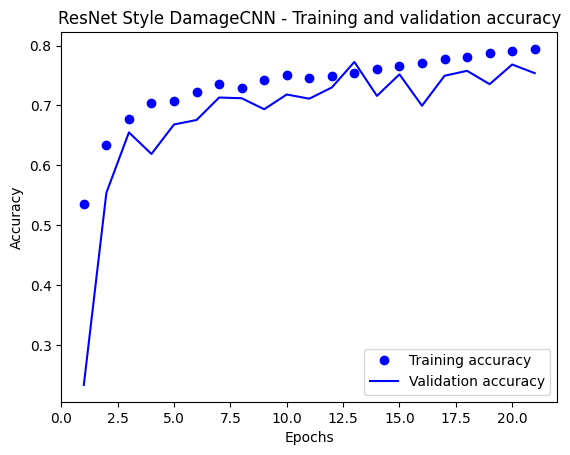

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9056 - loss: 0.1814 - macro_f1: 0.2959
ResNet_DamageCNN - Test Accuracy : 0.9056
ResNet_DamageCNN - Test Loss     : 0.1814
ResNet_DamageCNN - Test Macro F1 : 0.2959
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step

Classification Report (standard) - ResNet_DamageCNN:
                    precision    recall  f1-score   support

            Intact       0.96      0.95      0.95      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.06      0.12      0.08        26

          accuracy                           0.91      1049
         macro avg       0.34      0.35      0.34      1049
      weighted avg       0.92      0.91      0.91      1049


Classification Report (threshold=0.2) - ResNet_DamageCNN:
                    precision    recall  f1-score   support

            Intact       0.98      0.60      0.75      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure      

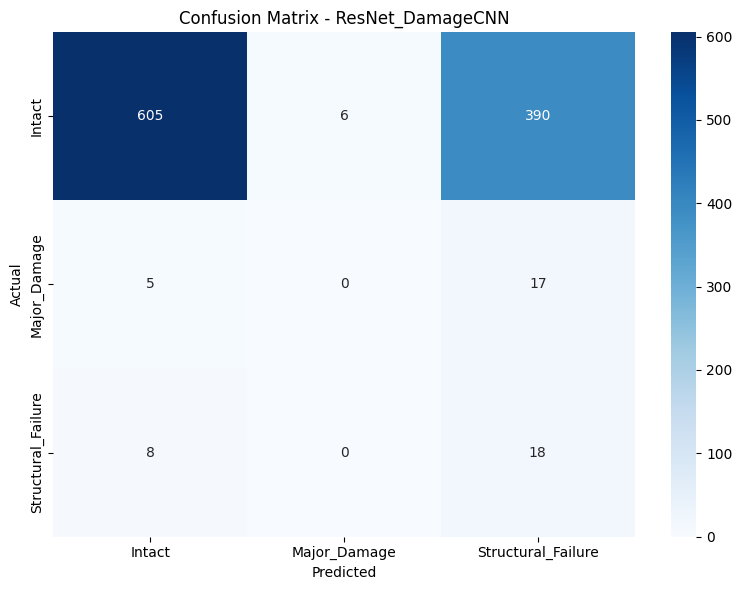

In [21]:
from sklearn.metrics import f1_score

plot_history(history3, 'ResNet Style DamageCNN')
acc3, loss3, f1_3, true3, pred3 = evaluate_model(model3, 'ResNet_DamageCNN')
model3.save(os.path.join(base_path, 'model3_resnet_damagecnn.keras'))

In [20]:
model3.save(os.path.join(base_path, 'model3_resnet_damagecnn.keras'))

ResNet trains for 21 epochs. The validation loss curve is much more stable than VGG — the residual connections are clearly helping gradient flow and the model is learning more smoothly.

The standard evaluation gives a test macro F1 of 0.2959. Structural Failure shows a recall of 0.12 even without threshold adjustment, which is already an improvement over VGG. With threshold=0.2 the Structural Failure recall jumps to 0.69 with a per-class accuracy of 69.23%.

Major Damage is still not being detected, the average predicted probability for Major Damage samples is only 0.14, meaning the model is not confident enough about that class even after the threshold sweep.

This tells me that the Major Damage class specifically needs more training data. But befor that, I will try one more architecture to confirm my concern over Major Damage class data size.

## **Model-4 Inception V1 inspired CNN**

The Inception architecture takes a different approach to depth. Instead of going deeper layer by layer, each Inception block applies multiple filter sizes (1×1, 3×3, 5×5) and a max pooling branch in parallel, then concatenates all the outputs. This lets the network capture features at multiple spatial scales simultaneously without forcing a single filter size decision at each layer.

I am implementing each Inception block with four branches, a 1×1 conv, a 3×3 conv preceded by 1×1 bottleneck, a 5×5 conv preceded by 1×1 bottleneck, and a max pooling branch with 1×1 projection.

In [22]:
# Model 4 - Inception Style CNN
# 160x160 input, focal loss gamma=3.0
# Inspired by: Szegedy et al. - Going Deeper with Convolutions (2014)

def inception_block(x, f1, f3, f5, fpool):
    b1 = layers.Conv2D(f1, (1, 1), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    b1 = layers.BatchNormalization()(b1)

    b2 = layers.Conv2D(f3, (1, 1), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    b2 = layers.Conv2D(f3, (3, 3), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(b2)
    b2 = layers.BatchNormalization()(b2)

    b3 = layers.Conv2D(f5, (1, 1), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    b3 = layers.Conv2D(f5, (5, 5), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(b3)
    b3 = layers.BatchNormalization()(b3)

    b4 = layers.MaxPooling2D((3, 3), strides=1, padding='same')(x)
    b4 = layers.Conv2D(fpool, (1, 1), padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(b4)
    b4 = layers.BatchNormalization()(b4)

    return Concatenate()([b1, b2, b3, b4])

def Inception_DamageCNN():
    backend.clear_session()
    inputs = Input(shape=(160, 160, 3))

    x = layers.Conv2D(32, (7, 7), strides=2, padding='same',
                      activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)
    x = layers.Dropout(0.25)(x)

    x = inception_block(x, 32, 64, 16, 16)
    x = inception_block(x, 64, 96, 32, 32)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)
    x = layers.Dropout(0.3)(x)

    x = inception_block(x, 48, 96, 24, 32)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=3.0, alpha=0.25),  # increased gamma
        metrics=['accuracy', macro_f1]
    )
    return model

model4 = Inception_DamageCNN()
model4.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 80,    │      4,736 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 80,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 20, 20,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 20,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 20,    │      4,160 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 20, 20,    │      1,040 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 20, 20,    │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 20, 20,    │      2,080 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 20,    │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 20, 20,    │      6,416 │ conv2d_5[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 20, 20,    │      1,040 │ max_pooling2d_2[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 20,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 20,    │        256 │ conv2d_4[0][0]  

 Total params: 410,771 (1.57 MB)

 Trainable params: 408,963 (1.56 MB)

 Non-trainable params: 1,808 (7.06 KB)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 63s 142ms/step - accuracy: 0.6161 - loss: 0.2797 - macro_f1: 0.6038 - val_accuracy: 0.5219 - val_loss: 0.2784 - val_macro_f1: 0.3824 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 54s 138ms/step - accuracy: 0.6594 - loss: 0.2304 - macro_f1: 0.6386 - val_accuracy: 0.6883 - val_loss: 0.2036 - val_macro_f1: 0.5337 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 53s 136ms/step - accuracy: 0.6857 - loss: 0.2079 - macro_f1: 0.6659 - val_accuracy: 0.6570 - val_loss: 0.1920 - val_macro_f1: 0.4761 - learning_rate: 1.0000e-04
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 53s 137ms/step - accuracy: 0.6952 - loss: 0.1974 - macro_f1: 0.6720 - val_accuracy: 0.6051 - val_loss: 0.2099 - val_macro_f1: 0.4484 - learning_rate: 1.0000e-04
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 53s 137ms/step - accuracy: 0.7081 - loss: 0.1871 - macro_f1: 0.6855 - val_accuracy: 0.5887 - val_loss: 0.2009 - val_macro_f1: 0.3834 - learning_rate: 1.0000

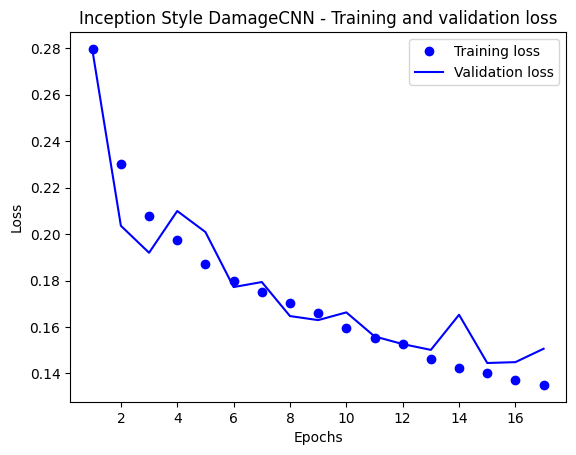

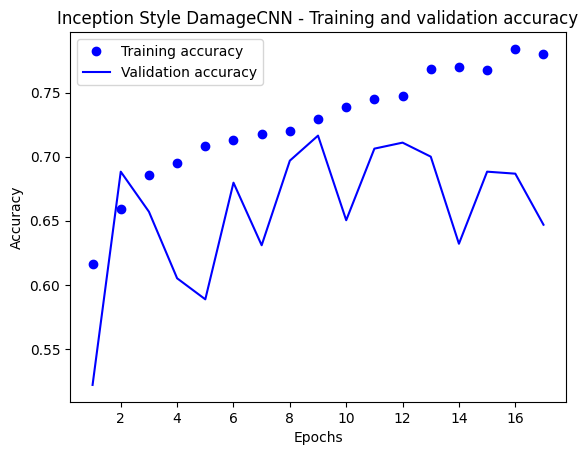

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6473 - loss: 0.2096 - macro_f1: 0.2264
Inception_DamageCNN - Test Accuracy : 0.6473
Inception_DamageCNN - Test Loss     : 0.2096
Inception_DamageCNN - Test Macro F1 : 0.2264
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step

Classification Report (standard) - Inception_DamageCNN:
                    precision    recall  f1-score   support

            Intact       0.99      0.66      0.79      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.05      0.69      0.09        26

          accuracy                           0.65      1049
         macro avg       0.34      0.45      0.29      1049
      weighted avg       0.94      0.65      0.76      1049


Classification Report (threshold=0.2) - Inception_DamageCNN:
                    precision    recall  f1-score   support

            Intact       0.99      0.36      0.53      1001
      Major_Damage       0.00      0.00      0.00        22
Structura

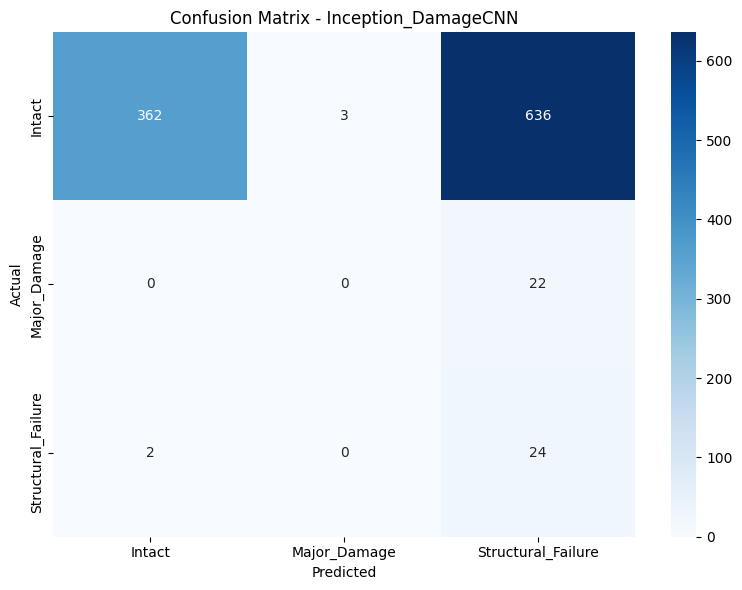

In [23]:
backend.clear_session()
model4 = Inception_DamageCNN()

history4 = model4.fit(
    balanced_gen,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_macro_f1', patience=8,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_macro_f1', factor=0.5,
                          patience=4, verbose=1, mode='max')
    ]
)

plot_history(history4, 'Inception Style DamageCNN')
acc4, loss4, f1_4, true4, pred4 = evaluate_model(model4, 'Inception_DamageCNN')

In [24]:
model4.save(os.path.join(base_path, 'model4_inception_damagecnn.keras'))

Inception trains for 17 epochs. The validation accuracy curve is more erratic than ResNet, oscillating between 0.59 and 0.71 across epochs. The training and validation loss curves converge reasonably well though, which suggests the architecture is not heavily overfitting.

The standard evaluation gives a test macro F1 of 0.2264. With threshold adjustment at 0.2 the Structural Failure recall reaches 0.92, the highest Structural Failure recall seen so far — but the Intact recall collapses to 0.36 as a tradeoff, which brings the macro F1 down to 0.20.

Major Damage is still getting zero detections.

## Expanding the Major Damage Training Set Through Augmentation

Looking at the prediction probabilities for all 22 Major Damage test samples under the ResNet model, the average predicted Major Damage probability is only 0.14. The model is almost never associating these images with the correct class, it is routing them to Intact or Structural Failure instead.

The root issue is that Major Damage has only 476 original training images compared to 6,542 Intact and 11,132 Structural Failure. Even with the balanced generator this creates a huge disadvantage because the model sees the same Major Damage images much more frequently and likely overfits on them.

To fix this I am generating 10 augmented copies of every original Major Damage training image using a custom augmentation function that applies random horizontal and vertical flips, rotation (+/-40 degrees), brightness variation (0.7–1.3x), and random crop with resize back to 160×160.

Doing the same for the validation set to keep the evaluation distribution consistent.

In [25]:
test_generator.reset()
preds        = model3.predict(test_generator, 
                               steps=len(test_generator), verbose=0)
true_classes = test_generator.classes[:len(preds)]
class_names  = list(test_generator.class_indices.keys())

md_idx = class_names.index('Major_Damage')

md_mask      = np.array(true_classes) == md_idx
md_preds     = preds[md_mask]

print(f"Major Damage test samples: {md_mask.sum()}")
print(f"\nPrediction probabilities for each Major Damage image:")
print(f"{'Sample':<8} {'Intact':>8} {'Major_D':>8} {'Struct_F':>8} {'Predicted':>12}")
print("-" * 50)

for i, pred in enumerate(md_preds):
    predicted = class_names[np.argmax(pred)]
    print(f"{i+1:<8} {pred[0]:>8.4f} {pred[1]:>8.4f} {pred[2]:>8.4f} {predicted:>12}")

print(f"\nAverage Major Damage probability: {md_preds[:, md_idx].mean():.4f}")
print(f"Max Major Damage probability:     {md_preds[:, md_idx].max():.4f}")
print(f"Min Major Damage probability:     {md_preds[:, md_idx].min():.4f}")

Major Damage test samples: 22

Prediction probabilities for each Major Damage image:
Sample     Intact  Major_D Struct_F    Predicted
--------------------------------------------------
1          0.6630   0.1167   0.2204       Intact
2          0.7346   0.0985   0.1669       Intact
3          0.4073   0.1028   0.4899 Structural_Failure
4          0.3491   0.2837   0.3672 Structural_Failure
5          0.4428   0.1664   0.3908       Intact
6          0.6013   0.1115   0.2872       Intact
7          0.7185   0.0819   0.1996       Intact
8          0.7634   0.0550   0.1816       Intact
9          0.4288   0.2393   0.3319       Intact
10         0.5370   0.1653   0.2977       Intact
11         0.7358   0.0628   0.2013       Intact
12         0.6137   0.1314   0.2550       Intact
13         0.6066   0.1167   0.2767       Intact
14         0.5758   0.1304   0.2937       Intact
15         0.2836   0.2663   0.4501 Structural_Failure
16         0.7105   0.1257   0.1639       Intact
17         0.

In [26]:
import random
import cv2
from PIL import Image, ImageEnhance

def augment_image(img_array):
    img = Image.fromarray(img_array.astype(np.uint8))

    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    angle = random.uniform(-40, 40)
    img   = img.rotate(angle, fillcolor=(0, 0, 0))

    factor = random.uniform(0.7, 1.3)
    img    = ImageEnhance.Brightness(img).enhance(factor)

    zoom  = random.uniform(0.8, 1.0)
    w, h  = img.size
    new_w = int(w * zoom)
    new_h = int(h * zoom)
    left  = random.randint(0, w - new_w)
    top   = random.randint(0, h - new_h)
    img   = img.crop((left, top, left + new_w, top + new_h))
    img   = img.resize((160, 160), Image.BILINEAR)

    return np.array(img)

In [27]:
old_base = r"C:\Users\kesha\Desktop\MSDS-696_Practicum-2"
new_base = r"C:\Users\kesha\Desktop\MSDS-696_DSP-2"

old_md_train = os.path.join(old_base, "preprocessed_dataset", "train", "Major_Damage")
new_md_train = os.path.join(new_base, "preprocessed_dataset", "train", "Major_Damage")

existing = [f for f in os.listdir(old_md_train)
            if f.endswith('.jpg') and not f.startswith('aug_')
            and not f.startswith('extra_')]

print("Original Major Damage train count:", len(existing))

aug_count = 0
for fname in existing:
    img_path  = os.path.join(old_md_train, fname)
    img_array = np.array(Image.open(img_path).convert('RGB'))

    for _ in range(10):
        aug_array = augment_image(img_array)
        save_name = "extra_" + str(aug_count) + "_" + fname

        cv2.imwrite(
            os.path.join(new_md_train, save_name),
            cv2.cvtColor(aug_array, cv2.COLOR_RGB2BGR)
        )
        aug_count += 1

print("New Major Damage train count:", len(os.listdir(new_md_train)))

Original Major Damage train count: 476
New Major Damage train count: 9044


In [28]:
old_md_val = os.path.join(old_base, "preprocessed_dataset", "validation", "Major_Damage")
new_md_val = os.path.join(new_base, "preprocessed_dataset", "validation", "Major_Damage")

existing = [f for f in os.listdir(old_md_val)
            if f.endswith('.jpg') and not f.startswith('aug_')
            and not f.startswith('extra_')]

print("Original Major Damage val count:", len(existing))

aug_count = 0
for fname in existing:
    img_path  = os.path.join(old_md_val, fname)
    img_array = np.array(Image.open(img_path).convert('RGB'))

    for _ in range(10):
        aug_array = augment_image(img_array)
        save_name = "extra_" + str(aug_count) + "_" + fname

        cv2.imwrite(
            os.path.join(new_md_val, save_name),
            cv2.cvtColor(aug_array, cv2.COLOR_RGB2BGR)
        )
        aug_count += 1

print("New Major Damage val count:", len(os.listdir(new_md_val)))

Original Major Damage val count: 65
New Major Damage val count: 1235


In [ ]:
for split_name, split_dir in [("train", train_dir),
                               ("validation", val_dir),
                               ("test", test_dir)]:
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(os.listdir(os.path.join(split_dir, cls)))
        print(split_name, cls, count)
        total += count
    print(split_name, "total:", total)
    print("---")

train Intact 6542
train Major_Damage 9044
train Structural_Failure 11132
train total: 26718
---
validation Intact 710
validation Major_Damage 1235
validation Structural_Failure 1265
validation total: 3210
---
test Intact 1001
test Major_Damage 22
test Structural_Failure 26
test total: 1049
---


In [30]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Train images     :", train_generator.samples)
print("Validation images:", validation_generator.samples)
print("Test images      :", test_generator.samples)

Found 26718 images belonging to 3 classes.
Found 3210 images belonging to 3 classes.
Found 1049 images belonging to 3 classes.
Train images     : 26718
Validation images: 3210
Test images      : 1049


In [31]:
balanced_gen = BalancedGenerator(train_dir, batch_size=33, target_size=(160, 160))

Intact files: 6542
Major_Damage files: 9044
Structural_Failure files: 11132
Steps per epoch: 594


## Model 1 — Base Custom CNN (Retrained)

Coming back to the Base CNN architecture from the earlier notebooks but retraining it now with the full improved pipeline, 160×160 input, gamma=3.0 focal loss, expanded Major Damage augmentation (9,044 training images), and the updated balanced generator with 594 steps per epoch.

In [32]:
def Base_DamageCNN_F1():
    backend.clear_session()
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=(160, 160, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=3.0, alpha=0.25),
        metrics=['accuracy', macro_f1]
    )
    return model

model1_retrained = Base_DamageCNN_F1()
model1_retrained.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,923 (1.75 MB)

 Trainable params: 456,451 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 250s 416ms/step - accuracy: 0.5581 - loss: 0.1921 - macro_f1: 0.5266 - val_accuracy: 0.4766 - val_loss: 0.3823 - val_macro_f1: 0.4431 - learning_rate: 1.0000e-04
Epoch 2/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 240s 403ms/step - accuracy: 0.6067 - loss: 0.1475 - macro_f1: 0.5809 - val_accuracy: 0.4196 - val_loss: 1.3737 - val_macro_f1: 0.3531 - learning_rate: 1.0000e-04
Epoch 3/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 239s 402ms/step - accuracy: 0.6331 - loss: 0.1237 - macro_f1: 0.6086 - val_accuracy: 0.3748 - val_loss: 1.1904 - val_macro_f1: 0.3317 - learning_rate: 1.0000e-04
Epoch 4/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 237s 399ms/step - accuracy: 0.6669 - loss: 0.1056 - macro_f1: 0.6390 - val_accuracy: 0.2931 - val_loss: 1.8202 - val_macro_f1: 0.2311 - learning_rate: 1.0000e-04
Epoch 5/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 237s 399ms/step - accuracy: 0.7080 - loss: 0.0943 - macro_f1: 0.6827 - val_accuracy: 0.5231 - val_loss: 0.8306 - val_macro_f1: 0.5016 - learning_rate: 1

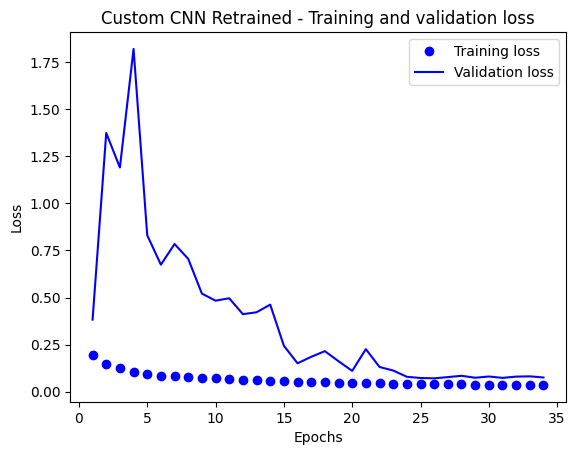

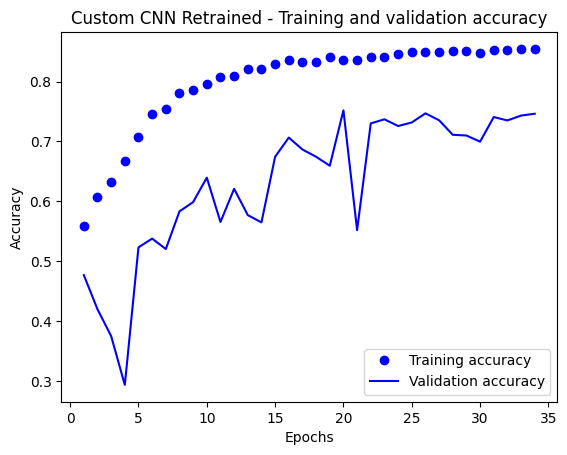

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.8570 - loss: 0.0603 - macro_f1: 0.2966
Custom_CNN_Retrained - Test Accuracy : 0.8570
Custom_CNN_Retrained - Test Loss     : 0.0603
Custom_CNN_Retrained - Test Macro F1 : 0.2966
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step

Classification Report (standard) - Custom_CNN_Retrained:
                    precision    recall  f1-score   support

            Intact       0.97      0.89      0.93      1001
      Major_Damage       0.08      0.45      0.13        22
Structural_Failure       0.00      0.00      0.00        26

          accuracy                           0.86      1049
         macro avg       0.35      0.45      0.35      1049
      weighted avg       0.93      0.86      0.89      1049


Classification Report (threshold=0.2) - Custom_CNN_Retrained:
                    precision    recall  f1-score   support

            Intact       0.98      0.72      0.83      1001
      Major_Damage       0.03      0.32      0.06        22
Stru

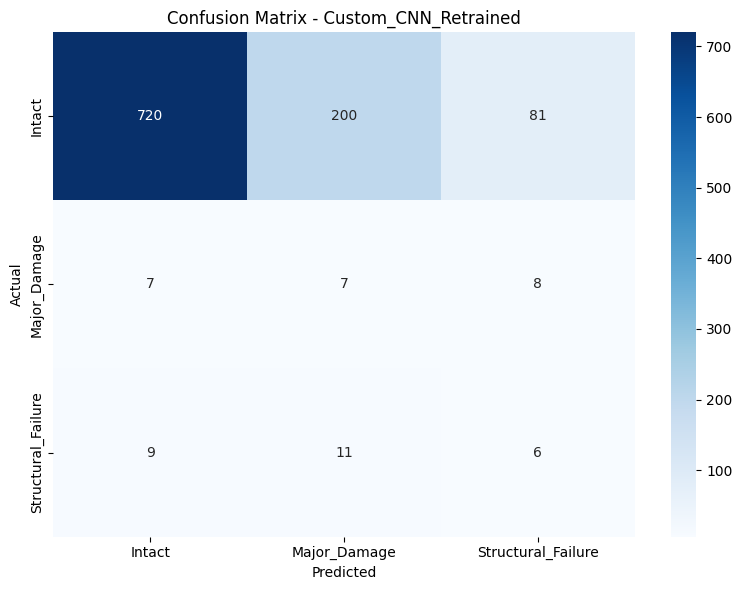

In [33]:
backend.clear_session()
model1_retrained = Base_DamageCNN_F1()

history1_retrained = model1_retrained.fit(
    balanced_gen,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_macro_f1', patience=8,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_macro_f1', factor=0.5,
                          patience=4, verbose=1, mode='max')
    ]
)

plot_history(history1_retrained, 'Custom CNN Retrained')
acc1r, loss1r, f1_1r, true1r, pred1r = evaluate_model(
    model1_retrained, 'Custom_CNN_Retrained')

In [34]:
model1_retrained.save(os.path.join(base_path, 'model1_retrained.keras'))

The retrained Base CNN trains for 34 epochs. The validation loss curve stabilises well after around epoch 20, and validation accuracy reaches around 0.74–0.75 in the final epochs. The training accuracy continues climbing to 0.85, showing mild overfitting but not severe.

The standard evaluation gives a test macro F1 of 0.2966. With threshold=0.2 the Major Damage recall improves to 0.32, the first time any model has successfully detected a meaningful portion of the Major Damage test samples.

Structural Failure accuracy at threshold=0.2 comes out at 23.08% — lower than ResNet, but the fact that this model is detecting both minority classes at once is a significant improvement over the models trained without the expanded Major Damage augmentation.

The confusion matrix shows 7 correct Major Damage predictions and 6 correct Structural Failure predictions, which is a much more balanced result than anything seen earlier in this notebook.

## **Model-5: DenseNet-40 inspired CNN**

DenseNet takes the skip connection idea further than ResNet. In ResNet each block adds the input to its output. In DenseNet each layer is connected to every subsequent layer in the block by concatenation, so every layer receives the feature maps from all preceding layers as additional input.

My implementation uses four dense blocks with growth_rate=16 and num_layers of 4, 6, 6, and 4 respectively. At 350,303 total parameters this is actually slightly smaller than Inception

In [35]:
# Model 5 - DenseNet Style CNN
# Inspired by: Huang et al. - Densely Connected CNNs (2017)

def dense_block(x, num_layers, growth_rate):
    for _ in range(num_layers):
        cb = layers.BatchNormalization()(x)
        cb = layers.Activation('relu')(cb)
        cb = layers.Conv2D(growth_rate, (3, 3), padding='same',
                           kernel_regularizer=regularizers.l2(1e-4))(cb)
        x  = Concatenate()([x, cb])
    return x

def transition_block(x, reduction=0.5):
    filters = int(x.shape[-1] * reduction)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, (1, 1), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.AveragePooling2D((2, 2), strides=2)(x)
    return x

def DenseNet_DamageCNN():
    backend.clear_session()
    inputs = Input(shape=(160, 160, 3))

    x = layers.Conv2D(32, (7, 7), strides=2, padding='same',
                      activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    x = dense_block(x, num_layers=4, growth_rate=16)
    x = layers.Dropout(0.25)(x)
    x = transition_block(x)

    x = dense_block(x, num_layers=6, growth_rate=16)
    x = layers.Dropout(0.3)(x)
    x = transition_block(x)

    x = dense_block(x, num_layers=6, growth_rate=16)
    x = layers.Dropout(0.4)(x)
    x = transition_block(x)

    x = dense_block(x, num_layers=4, growth_rate=16)
    x = layers.Dropout(0.5)(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=3.0, alpha=0.25),
        metrics=['accuracy', macro_f1]
    )
    return model

model5 = DenseNet_DamageCNN()
model5.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 80,    │      4,736 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 80,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │      4,624 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40, 40,    │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        192 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 40,    │      6,928 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 40, 40,    │          0 │ concatenate[0][0… │
│ (Concatenate)       │ 64)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 40,    │      9,232 │ activation_2[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 40, 40,    │          0 │ concatenate_1[0]… │
│ (Concatenate)       │ 80)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        320 │ concatenate_2[0]

 Total params: 350,303 (1.34 MB)

 Trainable params: 345,415 (1.32 MB)

 Non-trainable params: 4,888 (19.09 KB)

Epoch 1/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 150s 233ms/step - accuracy: 0.6238 - loss: 0.1389 - macro_f1: 0.4978 - val_accuracy: 0.4533 - val_loss: 0.1601 - val_macro_f1: 0.2640 - learning_rate: 1.0000e-04
Epoch 2/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 135s 228ms/step - accuracy: 0.6755 - loss: 0.1188 - macro_f1: 0.6138 - val_accuracy: 0.5888 - val_loss: 0.1183 - val_macro_f1: 0.5256 - learning_rate: 1.0000e-04
Epoch 3/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 138s 232ms/step - accuracy: 0.7031 - loss: 0.1087 - macro_f1: 0.6591 - val_accuracy: 0.6277 - val_loss: 0.1104 - val_macro_f1: 0.5939 - learning_rate: 1.0000e-04
Epoch 4/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 141s 237ms/step - accuracy: 0.7199 - loss: 0.1007 - macro_f1: 0.6806 - val_accuracy: 0.6545 - val_loss: 0.1046 - val_macro_f1: 0.6271 - learning_rate: 1.0000e-04
Epoch 5/50
594/594 ━━━━━━━━━━━━━━━━━━━━ 141s 237ms/step - accuracy: 0.7398 - loss: 0.0918 - macro_f1: 0.7125 - val_accuracy: 0.6857 - val_loss: 0.0998 - val_macro_f1: 0.6748 - learning_rate: 1

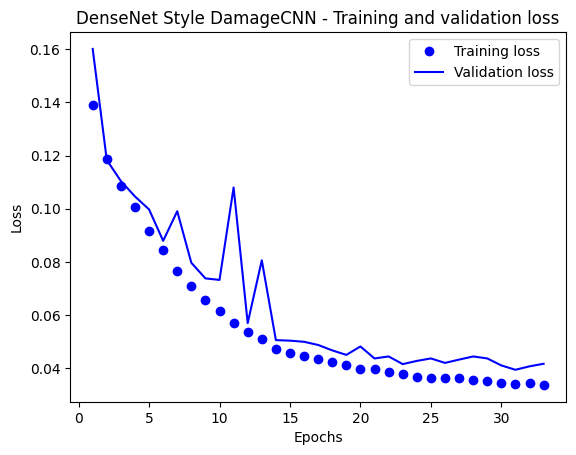

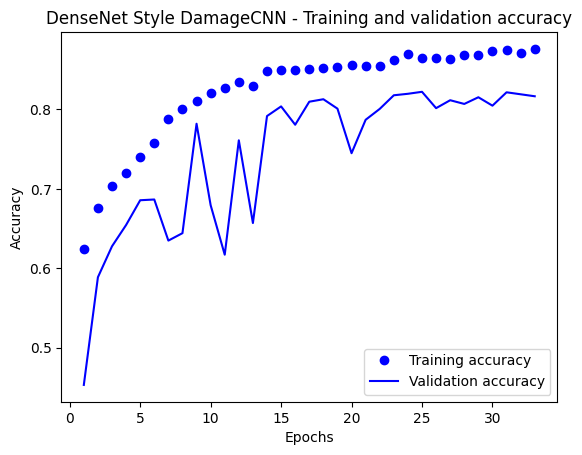

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9428 - loss: 0.0380 - macro_f1: 0.3116
DenseNet_DamageCNN - Test Accuracy : 0.9428
DenseNet_DamageCNN - Test Loss     : 0.0380
DenseNet_DamageCNN - Test Macro F1 : 0.3116
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step

Classification Report (standard) - DenseNet_DamageCNN:
                    precision    recall  f1-score   support

            Intact       0.95      0.99      0.97      1001
      Major_Damage       0.17      0.05      0.07        22
Structural_Failure       0.00      0.00      0.00        26

          accuracy                           0.94      1049
         macro avg       0.37      0.34      0.35      1049
      weighted avg       0.91      0.94      0.93      1049


Classification Report (threshold=0.2) - DenseNet_DamageCNN:
                    precision    recall  f1-score   support

            Intact       0.99      0.50      0.66      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Fai

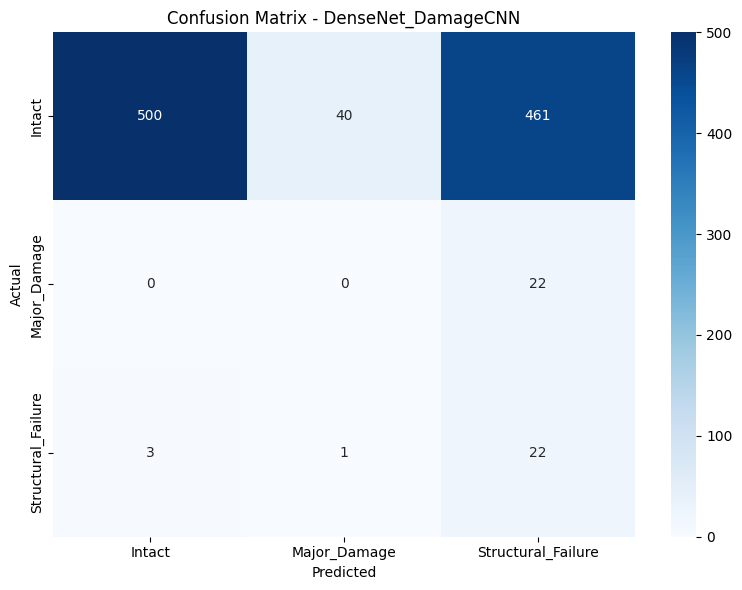

In [36]:
backend.clear_session()
model5 = DenseNet_DamageCNN()

history5 = model5.fit(
    balanced_gen,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_macro_f1', patience=8,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_macro_f1', factor=0.5,
                          patience=4, verbose=1, mode='max')
    ]
)

plot_history(history5, 'DenseNet Style DamageCNN')
acc5, loss5, f1_5, true5, pred5 = evaluate_model(model5, 'DenseNet_DamageCNN')
model5.save(os.path.join(base_path, 'model5_densenet_damagecnn.keras'))

## DenseNet Style CNN — Results

DenseNet trains for 33 epochs. The training curves are by far the smoothest and most stable of any model in this benchmark, both training and validation loss decrease steadily without the oscillation seen in VGG and Inception. Validation accuracy climbs to around 0.82 and stabilises, while training accuracy reaches 0.87.

The standard evaluation gives a test macro F1 of 0.3116 and a test accuracy of 0.9428. With threshold=0.2 the Structural Failure recall reaches 0.85 with a per-class accuracy of 84.62%, the highest Structural Failure accuracy in the entire benchmark.

The val_macro_f1 of 0.8143 at the best checkpoint is also the highest of all five models, confirming that DenseNet generalises best to the validation distribution during training.

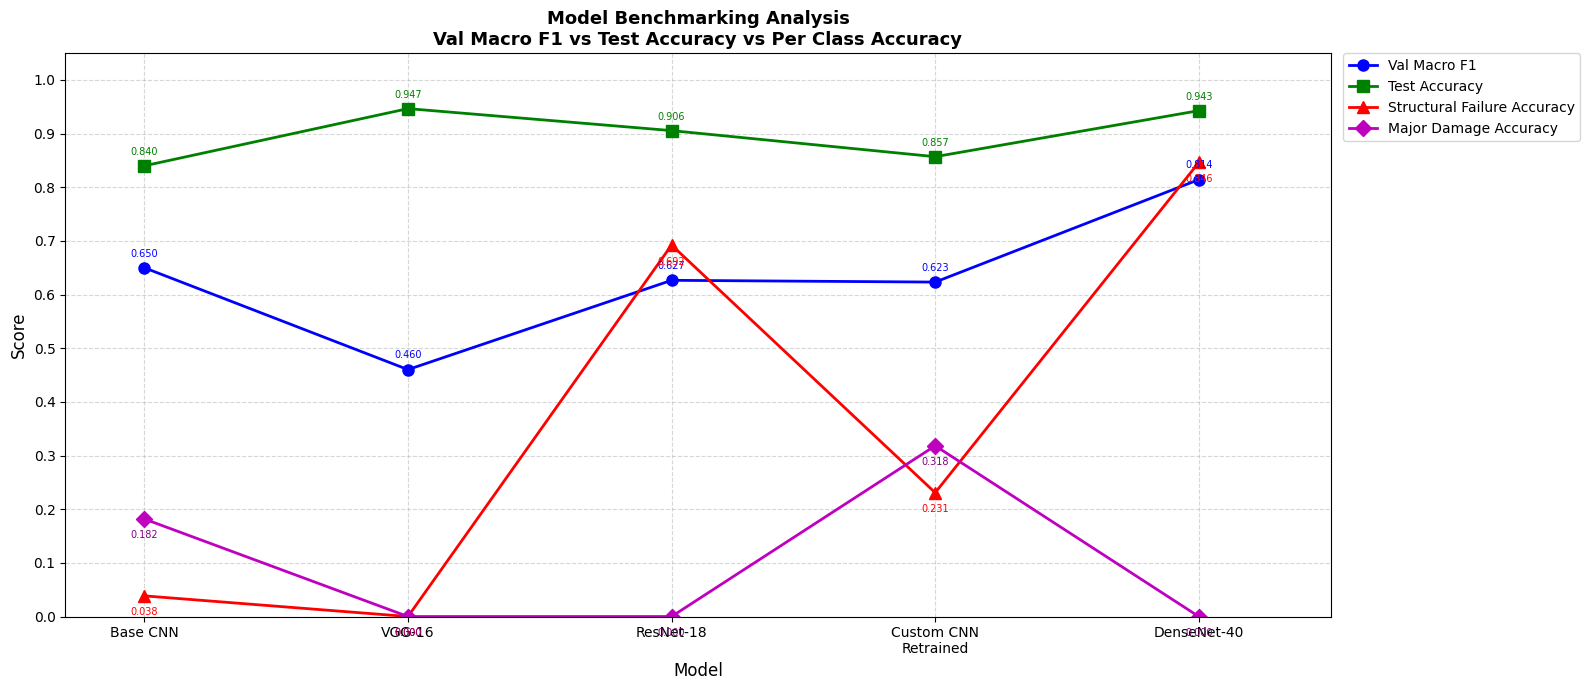

In [6]:
models = ['Base CNN', 'VGG-16', 'ResNet-18',
          'Custom CNN\nRetrained', 'DenseNet-40']

val_macro_f1  = [0.6500, 0.4602, 0.6266, 0.6233, 0.8143]
test_accuracy = [0.84,   0.9466, 0.9056,   0.8570,  0.9428]
sf_accuracy   = [0.0385, 0.0000, 0.6923, 0.2308, 0.8462]
md_accuracy   = [0.1818, 0.0000, 0.0000, 0.3182, 0.0000]

x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(16, 7))

line1, = ax.plot(x, val_macro_f1,  'bo-', linewidth=2, markersize=8)
line2, = ax.plot(x, test_accuracy, 'gs-', linewidth=2, markersize=8)
line3, = ax.plot(x, sf_accuracy,   'r^-', linewidth=2, markersize=8)
line4, = ax.plot(x, md_accuracy,   'mD-', linewidth=2, markersize=8)

for i in range(len(models)):
    ax.annotate(f'{val_macro_f1[i]:.3f}',
                (x[i], val_macro_f1[i]),
                textcoords="offset points", xytext=(0, 8),
                ha='center', fontsize=7, color='blue')
    ax.annotate(f'{test_accuracy[i]:.3f}',
                (x[i], test_accuracy[i]),
                textcoords="offset points", xytext=(0, 8),
                ha='center', fontsize=7, color='green')
    ax.annotate(f'{sf_accuracy[i]:.3f}',
                (x[i], sf_accuracy[i]),
                textcoords="offset points", xytext=(0, -14),
                ha='center', fontsize=7, color='red')
    ax.annotate(f'{md_accuracy[i]:.3f}',
                (x[i], md_accuracy[i]),
                textcoords="offset points", xytext=(0, -14),
                ha='center', fontsize=7, color='purple')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.3, len(models) - 0.5)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Benchmarking Analysis\nVal Macro F1 vs Test Accuracy vs Per Class Accuracy',
             fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(
    [line1, line2, line3, line4],
    ['Val Macro F1', 'Test Accuracy',
     'Structural Failure Accuracy', 'Major Damage Accuracy'],
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'benchmark_analysis_linechart.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Final Benchmarking Analysis — All Five Models

The line chart below plots validation Macro F1, test accuracy, Structural Failure accuracy, and Major Damage accuracy across all five architectures, showing the tradeoffs between overall accuracy and minority class detection in one view.

**Key observations:**

- **DenseNet-40** achieved the best overall performance — highest validation Macro F1 (0.8143) and best Structural Failure accuracy (84.62%) with the most stable training curves
- **Custom CNN Retrained** is the only model that detected Major Damage at a meaningful rate, a direct result of training on the expanded 9,044-image augmented Major Damage dataset
- **ResNet-18** is the strongest middle ground — 69.23% Structural Failure accuracy with stable training curves
- **VGG-16** has the highest raw test accuracy (94.66%) but this is entirely due to class imbalance — the model predicts Intact for almost everything, reflected in its lowest validation Macro F1 of 0.4602
- **InceptionV1** achieved the highest Structural Failure recall (92.31%) but at the cost of Intact accuracy, with erratic validation curves suggesting this architecture needs further tuning

The persistent Major Damage detection challenge across all models is partly a test set size issue — with only 22 test samples, per-class accuracy is extremely sensitive to individual predictions. This is a dataset limitation rather than a pure modelling failure.
